Imports

In [4]:
import pandas as pd
import os
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.cluster import OPTICS
import pandas as pd
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
import pyodbc
import pandas as pd
import geopandas as gpd




In [3]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np

# Define all clusters with their station names
clusters = {
    "Cluster 0": [
        "AFULA NIR HAEMEQ", "AMMIAD", "AVNE ETAN", 
        "AYYELET HASHARHAR", "BET ZAYDA", "DEIR HANNA", 
        "EDEN FARM", "ESHHAR", "GAMLA",  
        "KEFAR NAHUM", "MAALE GILBOA", 
        "MASSADA", "SEDE ELIYYAHU", "TAVOR KADOORIE", 
        "TEL YOSEF", "YAVNEEL", "ZEMAH"
    ],
    "Cluster 1": [
        "AFEQ", "EN HAHORESH", "EN HASHOFET", "EN KARMEL", "GALED", 
        "HADERA PORT", "HAIFA REFINERIES", "HAIFA TECHNION", "HAIFA UNIVERSITY", 
        "NEWE YAAR", "ROSH HANIQRA", "SHAVE ZIYYON", "ZIKHRON YAAQOV"
    ],
    "Cluster 2": [
        "HARASHIM", "MEROM GOLAN PICMAN", "ZEFAT HAR KENAAN", 
        "DAFNA", "KEFAR BLUM", "KEFAR GILADI"
    ],
    "Cluster 3": [
        "ELAT",   "YOTVATA","NEOT SMADAR","PARAN"
    ],
    "Cluster 4": [
        "ARAD", "ASHALIM", "AVDAT", "EZUZ",  
        "MIZPE RAMON",  "NEVATIM", "SEDE BOQER", 
        "SHANI", "ZOMET HANEGEV","LAHAV","BESOR FARM","HAZEVA"   #"BESOR FARM" moved here from cluster center,"HAZEVA" moved here from cluster arava 
    ],
    "Cluster 5": [
        "ASHDOD PORT", "ASHQELON PORT", "BEIT JIMAL",  "BET DAGAN", 
        "DOROT", "GAT", "HAFEZ HAYYIM",  "NAHSHON", "NEGBA", 
        "NIZZAN", "QEVUZAT YAVNE", "TEL AVIV COAST"
    ],
    "Cluster 6": [
        "HAR HARASHA", "JERUSALEM CENTRE", "JERUSALEM GIVAT RAM", "ROSH ZURIM", "ZOVA"
    ]
}

# Load station metadata from CSV
stations_df = pd.read_csv('C:\\תואר שני\\מחקר נגה\\Map plottings\\stations_meta_data.csv')

# Normalize station names
stations_df['Station'] = stations_df['Station'].str.upper()
stations_df['Station'] = stations_df['Station'].str.replace('STATION_', '').str.replace('_', ' ')

# Load Israel map from GeoJSON
israel_map = gpd.read_file('C:\\תואר שני\\מחקר נגה\\Map plottings\\il.json')

# Convert filtered DataFrame to GeoDataFrame for plotting
stations_df = gpd.GeoDataFrame(
    stations_df, geometry=gpd.points_from_xy(stations_df.Longitude, stations_df.Latitude)
)

# Assign a unique color to each cluster
num_clusters = len(clusters)
colors = plt.cm.get_cmap("tab10", num_clusters)  # Use a colormap with distinct colors

# Plot the map
fig, ax = plt.subplots(figsize=(12, 10))

# Plot the base map of Israel
israel_map.plot(ax=ax, color='lightgray', edgecolor='black')

# Iterate through each cluster and plot stations
for i, (cluster_name, cluster_stations) in enumerate(clusters.items()):
    # Filter stations belonging to the current cluster
    cluster_gdf = stations_df[stations_df['Station'].isin(cluster_stations)]
    
    # Plot stations with a unique color
    ax.scatter(cluster_gdf['Longitude'], cluster_gdf['Latitude'], 
               color=colors(i), label=cluster_name, s=100, edgecolor='black')

# Set labels and title
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Weather Station Clusters in Israel')

# Move the legend outside the plot
plt.legend(title="Clusters", bbox_to_anchor=(1.05, 1), loc='upper left')

# Show the plot
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\תואר שני\\מחקר נגה\\Map plottings\\stations_meta_data.csv'

Plot The Cluster

In [5]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np

# List of selected station names to plot
cluster = [
    "BET DAGAN", 
    "DOROT", 
    "NEGBA", 
    "QEVUZAT YAVNE"
]

# Load station metadata from CSV
stations_df = pd.read_csv('C:\\תואר שני\\מחקר נגה\\Map plottings\\stations_meta_data.csv')  # Adjust path

# Normalize station names for matching
stations_df['Station'] = stations_df['Station'].str.upper()
stations_df['Station'] = stations_df['Station'].str.replace('STATION_', '').str.replace('_', ' ')

# Filter to keep only the stations that are part of the specified cluster list
stations_df = stations_df[stations_df['Station'].isin(cluster)]

# Load Israel map from GeoJSON
israel_map = gpd.read_file('C:\\תואר שני\\מחקר נגה\\Map plottings\\il.json')  # Adjust path

# Convert filtered DataFrame to GeoDataFrame for plotting
gdf_clustered_stations = gpd.GeoDataFrame(
    stations_df, geometry=gpd.points_from_xy(stations_df.Longitude, stations_df.Latitude)
)

# Generate a unique color for each station
np.random.seed(42)  # For reproducibility
colors = plt.cm.tab10(np.linspace(0, 1, len(cluster)))  # Use colormap for distinct colors
station_colors = dict(zip(cluster, colors))  # Assign colors to stations

# Plot the map with clustered stations
fig, ax = plt.subplots(figsize=(10, 10))

# Plot the base map of Israel
israel_map.plot(ax=ax, color='lightgray', edgecolor='black')

# Plot the clustered stations with unique colors
scatter_plots = []
for station, color in station_colors.items():
    station_data = gdf_clustered_stations[gdf_clustered_stations['Station'] == station]
    sc = ax.scatter(
        station_data['Longitude'], station_data['Latitude'], 
        color=color, s=100, edgecolor='black'
    )
    scatter_plots.append(sc)  # Store scatter plot handles for the legend

# Set labels and title
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Cluster 6: Centre')

# Add legend with station names and colors
plt.legend(scatter_plots, cluster, title="Stations", loc="upper left")

# Show plot
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\תואר שני\\מחקר נגה\\Map plottings\\stations_meta_data.csv'

Create Rectangle

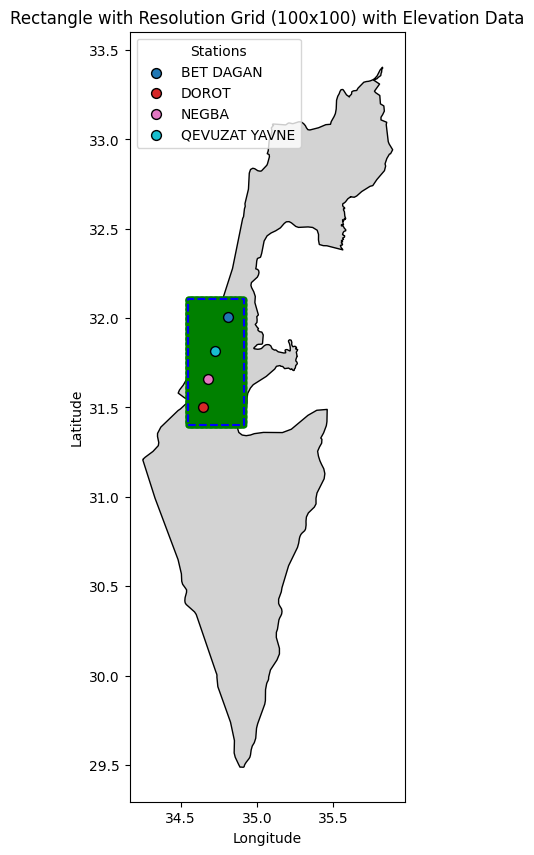

In [3]:
import os
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import rasterio

def plot_station_rectangle_with_grid_on_map(resolution, padding, stations_df, israel_map, bil_directory):
    """
    Plot a rectangle based on the most northern, southern, eastern, and western stations
    with padding, and mark the resolution pixels on the map. Return the matrix with pixel locations.

    Parameters:
    resolution (tuple): Resolution as (width_pixels, height_pixels).
    padding (tuple): Padding as (longitude_padding, latitude_padding).
    stations_df (DataFrame): DataFrame with station coordinates (Longitude, Latitude, Height).
    israel_map (GeoDataFrame): GeoDataFrame of the map of Israel.
    bil_directory (str): Directory containing the .bil files.

    Returns:
    numpy.ndarray: A matrix of pixel locations with their corresponding longitude, latitude, and height.
    """
    # Calculate the bounding box with padding
    min_lat = stations_df['Latitude'].min() - padding[1]
    max_lat = stations_df['Latitude'].max() + padding[1]
    min_lon = stations_df['Longitude'].min() - padding[0]
    max_lon = stations_df['Longitude'].max() + padding[0]

    # Extract resolution parameters
    width_pixels, height_pixels = resolution

    # Create the grid
    lon_grid = np.linspace(min_lon, max_lon, width_pixels + 1)
    lat_grid = np.linspace(min_lat, max_lat, height_pixels + 1)

    # Initialize pixel matrix with NaN for height
    pixel_matrix = np.array([[lon, lat, np.nan] for lon in lon_grid for lat in lat_grid]).reshape((width_pixels + 1, height_pixels + 1, 3))

    # Load all .bil files from the directory
    bil_files = [os.path.join(bil_directory, f) for f in os.listdir(bil_directory) if f.endswith('.bil')]
    dem_datasets = [rasterio.open(bil) for bil in bil_files]

    # Function to get elevation from DEMs
    def get_elevation(lon, lat):
        for dem in dem_datasets:
            if (dem.bounds.left <= lon <= dem.bounds.right) and (dem.bounds.bottom <= lat <= dem.bounds.top):
                row, col = dem.index(lon, lat)
                elevation = dem.read(1)[row, col]
                if elevation != dem.nodata:
                    return elevation
        return np.nan  # If no valid elevation found

    # Populate the pixel matrix with elevation data
    for i, lon in enumerate(lon_grid):
        for j, lat in enumerate(lat_grid):
            elevation = get_elevation(lon, lat)
            pixel_matrix[i, j] = [lon, lat, elevation]

    # Close DEM files
    for dem in dem_datasets:
        dem.close()

    # Generate unique colors for each station
    np.random.seed(42)  # Ensure color consistency
    colors = plt.cm.tab10(np.linspace(0, 1, len(stations_df)))
    station_colors = dict(zip(stations_df['Station'], colors))  # Assign colors to stations

    # Create the rectangle with grid
    fig, ax = plt.subplots(figsize=(10, 10))

    # Plot the base map of Israel
    israel_map.plot(ax=ax, color='lightgray', edgecolor='black')

    # Plot the bounding box as a rectangle
    ax.plot([min_lon, max_lon, max_lon, min_lon, min_lon],
            [min_lat, min_lat, max_lat, max_lat, min_lat],
            color='blue', linestyle='--', label='Bounding Box')

    # Mark grid points as dots
    ax.scatter(pixel_matrix[:, :, 0], pixel_matrix[:, :, 1], color='green', s=10, label='Grid Points (Pixels)')

    # Plot each station with its assigned color
    scatter_plots = []
    for station, color in station_colors.items():
        station_data = stations_df[stations_df['Station'] == station]
        sc = ax.scatter(
            station_data['Longitude'], station_data['Latitude'], 
            color=color, s=50, edgecolor='black'
        )
        scatter_plots.append((sc, station))  # Store for legend

    # Add legend with station names and colors
    ax.legend(
        [sc[0] for sc in scatter_plots], 
        [sc[1] for sc in scatter_plots], 
        title="Stations", loc="upper left"
    )

    # Set labels and title
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.title(f'Rectangle with Resolution Grid ({width_pixels}x{height_pixels}) with Elevation Data')

    # Show plot
    plt.show()

    return pixel_matrix

# Example usage
cluster = [
    "BET DAGAN",
    "DOROT", "NEGBA",
    "QEVUZAT YAVNE"
]

# Load station metadata
stations_df = pd.read_csv(r'C:\תואר שני\מחקר נגה\Map plottings\stations_meta_data.csv')
stations_df['Station'] = stations_df['Station'].str.upper()
stations_df['Station'] = stations_df['Station'].str.replace('STATION_', '').str.replace('_', ' ')
stations_df = stations_df[stations_df['Station'].isin(cluster)]

# Ensure Height column is numeric
stations_df['Height'] = pd.to_numeric(stations_df['height'], errors='coerce')

# Drop duplicate rows based on 'Station', 'Latitude', 'Longitude', and 'Height'
stations_df = stations_df.drop_duplicates(subset=['Station', 'Latitude', 'Longitude', 'Height'])

# Load Israel map
israel_map = gpd.read_file(r'C:\תואר שני\מחקר נגה\Map plottings\il.json')

# Directory containing .bil files
bil_directory = r'C:\תואר שני\מחקר נגה\height_data\bil files'

# Run the function
pixel_matrix = plot_station_rectangle_with_grid_on_map((100, 100), (0.1, 0.1), stations_df, israel_map, bil_directory)


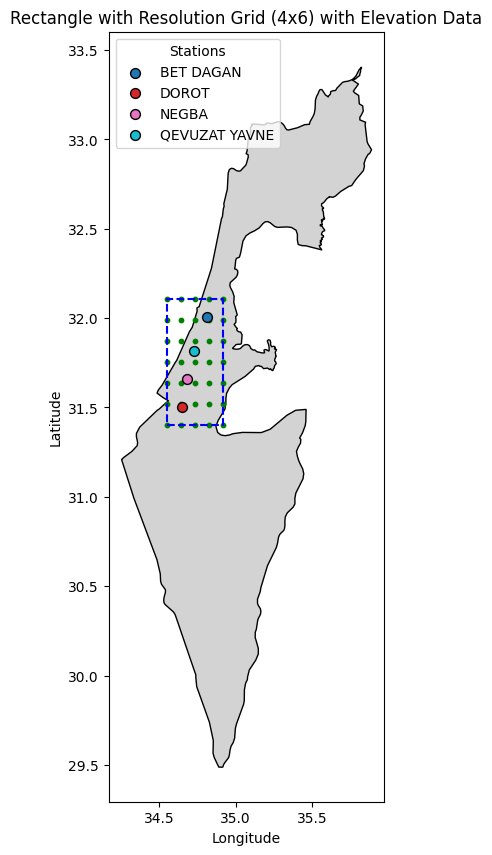

[[[ 34.548       31.4036     105.        ]
  [ 34.548       31.52088333  79.        ]
  [ 34.548       31.63816667  42.        ]
  [ 34.548       31.75545      0.        ]
  [ 34.548       31.87273333   0.        ]
  [ 34.548       31.99001667   0.        ]
  [ 34.548       32.1073       0.        ]]

 [[ 34.63945     31.4036     128.        ]
  [ 34.63945     31.52088333  97.        ]
  [ 34.63945     31.63816667  74.        ]
  [ 34.63945     31.75545     41.        ]
  [ 34.63945     31.87273333   0.        ]
  [ 34.63945     31.99001667   0.        ]
  [ 34.63945     32.1073       0.        ]]

 [[ 34.7309      31.4036     193.        ]
  [ 34.7309      31.52088333 156.        ]
  [ 34.7309      31.63816667  87.        ]
  [ 34.7309      31.75545     42.        ]
  [ 34.7309      31.87273333  42.        ]
  [ 34.7309      31.99001667  12.        ]
  [ 34.7309      32.1073       0.        ]]

 [[ 34.82235     31.4036     296.        ]
  [ 34.82235     31.52088333 229.        ]
  [ 3

In [4]:
# Define the directory where all .bil and .hdr files are stored
bil_directory = r'C:\תואר שני\מחקר נגה\height_data\bil files'

# Call the function with resolution (e.g., 4x6 grid) and padding (e.g., 0.1 degrees for longitude and latitude)
pixel_matrix = plot_station_rectangle_with_grid_on_map((4, 6), (0.1, 0.1), stations_df, israel_map, bil_directory)

# Print the pixel matrix (longitude, latitude, elevation)
print(pixel_matrix)


In [62]:
print(pixel_matrix[4][5])

[34.9138     31.99001667 50.        ]


PLOT ALL THE FRAMES 

Distance Exemple


Selected Pixel:
Longitude: 34.9138, Latitude: 31.52088333333333, Height: 385.0 meters

Calculations for Each Station:

Station: BET DAGAN
  Longitude: 34.8138, Latitude: 32.0073, Height: 31.0 meters
  Horizontal Distance: 54.761 km
  Elevation Difference: -354.0 m
  3D Distance: 54.762 km

Station: BET DAGAN
  Longitude: 34.8138, Latitude: 32.0073, Height: 31.0 meters
  Horizontal Distance: 54.761 km
  Elevation Difference: -354.0 m
  3D Distance: 54.762 km

Station: DOROT
  Longitude: 34.648, Latitude: 31.5036, Height: 115.0 meters
  Horizontal Distance: 25.321 km
  Elevation Difference: -270.0 m
  3D Distance: 25.322 km

Station: DOROT
  Longitude: 34.648, Latitude: 31.5036, Height: 115.0 meters
  Horizontal Distance: 25.321 km
  Elevation Difference: -270.0 m
  3D Distance: 25.322 km

Station: NEGBA
  Longitude: 34.6798, Latitude: 31.6585, Height: 95.0 meters
  Horizontal Distance: 26.946 km
  Elevation Difference: -290.0 m
  3D Distance: 26.948 km

Station: NEGBA
  Longitude: 34.6

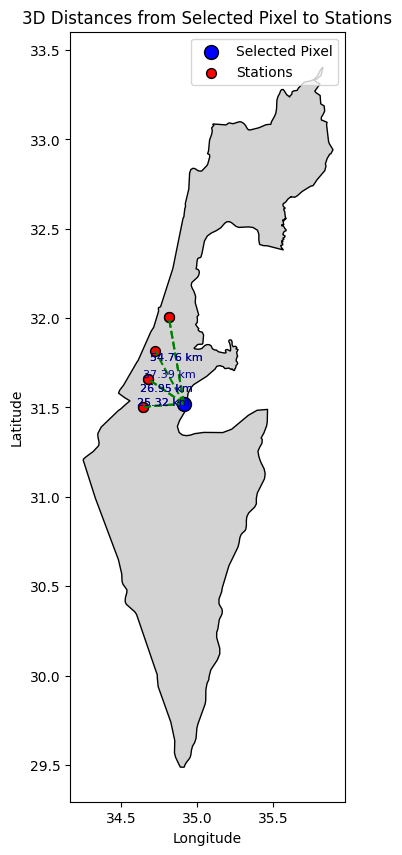

In [107]:
import numpy as np
from geopy.distance import geodesic
import matplotlib.pyplot as plt

def plot_pixel_to_station_distances(pixel, stations_df, israel_map):
    """
    Plot lines from a chosen pixel to all stations, annotate 3D distances (accounting for height differences) on the map,
    and print calculations.
    
    Args:
        pixel (tuple): Longitude, latitude, and elevation of the selected pixel (lon, lat, height).
        stations_df (GeoDataFrame): DataFrame containing station locations with 'Longitude', 'Latitude', and 'height'.
        israel_map (GeoDataFrame): GeoDataFrame of the Israel map for context.
    """
    # Ensure the pixel is correctly unpacked
    pixel_lon, pixel_lat, pixel_height = tuple(pixel)

    print(f"\nSelected Pixel:\nLongitude: {pixel_lon}, Latitude: {pixel_lat}, Height: {pixel_height} meters\n")

    # Calculate horizontal distances, elevation differences, and 3D distances
    stations_df['Horizontal Distance (km)'] = stations_df.apply(
        lambda row: geodesic((pixel_lat, pixel_lon), (row['Latitude'], row['Longitude'])).kilometers, axis=1
    )
    stations_df['Elevation Difference (m)'] = stations_df['height'] - pixel_height

    # Convert elevation difference to kilometers for 3D distance calculation
    stations_df['Elevation Difference (km)'] = stations_df['Elevation Difference (m)'] / 1000.0

    # Calculate the 3D distance using Pythagoras
    stations_df['3D Distance (km)'] = stations_df.apply(
        lambda row: np.sqrt(row['Horizontal Distance (km)']**2 + row['Elevation Difference (km)']**2), axis=1
    )

    # Print the calculations for each station
    print("Calculations for Each Station:")
    for _, row in stations_df.iterrows():
        print(f"\nStation: {row['Station']}")
        print(f"  Longitude: {row['Longitude']}, Latitude: {row['Latitude']}, Height: {row['height']} meters")
        print(f"  Horizontal Distance: {row['Horizontal Distance (km)']:.3f} km")
        print(f"  Elevation Difference: {row['Elevation Difference (m)']:.1f} m")
        print(f"  3D Distance: {row['3D Distance (km)']:.3f} km")

    # Create the plot
    fig, ax = plt.subplots(figsize=(10, 10))

    # Plot the base map of Israel
    israel_map.plot(ax=ax, color='lightgray', edgecolor='black')

    # Plot the chosen pixel
    ax.scatter(pixel_lon, pixel_lat, color='blue', s=100, label='Selected Pixel', edgecolor='black')

    # Plot the stations
    ax.scatter(
        stations_df['Longitude'], 
        stations_df['Latitude'], 
        color='red', s=50, label='Stations', edgecolor='black'
    )

    # Draw lines and annotate 3D distances
    for _, row in stations_df.iterrows():
        station_lon, station_lat = row['Longitude'], row['Latitude']
        distance_3d_km = row['3D Distance (km)']

        # Draw a line from the pixel to the station
        ax.plot([pixel_lon, station_lon], [pixel_lat, station_lat], color='green', linestyle='--')

        # Annotate the 3D distance on the map
        mid_lon, mid_lat = (pixel_lon + station_lon) / 2, (pixel_lat + station_lat) / 2
        annotation_text = f'{distance_3d_km:.2f} km'
        ax.text(mid_lon, mid_lat, annotation_text, fontsize=8, color='darkblue', ha='center')

    # Set labels, title, and legend
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.title('3D Distances from Selected Pixel to Stations')
    ax.legend()

    # Show the plot
    plt.show()

# Example usage
chosen_pixel = tuple(pixel_matrix[4, 1])  # Ensure it's properly unpacked as (lon, lat, height)
plot_pixel_to_station_distances(pixel=chosen_pixel, stations_df=gdf_clustered_stations, israel_map=israel_map)


Weights Clculation

In [32]:
import numpy as np
import math

def haversine_distance(lat1, lon1, lat2, lon2):
    """
    Calculate the great-circle distance between two points on Earth 
    (latitude/longitude in decimal degrees). Returns distance in KM.
    """
    R = 6371.0  # Earth radius in kilometers

    # Convert decimal degrees to radians
    phi1 = math.radians(lat1)
    phi2 = math.radians(lat2)
    dphi = phi2 - phi1
    dlambda = math.radians(lon2 - lon1)

    # Haversine formula
    a = (math.sin(dphi / 2) ** 2
         + math.cos(phi1) * math.cos(phi2) * math.sin(dlambda / 2) ** 2)
    c = 2 * math.asin(math.sqrt(a))

    return R * c  # distance in kilometers


def calculate_pixel_weights(pixel_matrix, stations_df, weight_function, p=2, k=1, r=10):
    """
    Calculate weights for each pixel in the pixel matrix based on a selected weighting function,
    incorporating normalized horizontal and height distances.

    Parameters:
    - pixel_matrix (numpy.ndarray): 3D array of pixel coordinates (longitude, latitude, height).
    - stations_df (DataFrame): DataFrame with station coordinates (Longitude, Latitude, height).
    - weight_function (str): Weighting function ("idw", "exponential", "linear", "constant").
    - p (int): Power parameter for IDW (default: 2).
    - k (float): Decay rate for exponential weighting (default: 1).
    - r (float): Radius for constant weighting in kilometers (default: 10).

    Returns:
    - numpy.ndarray: A 3D array of weights corresponding to each pixel and each station.
    """
    num_rows, num_cols, _ = pixel_matrix.shape
   
    station_coords = list(zip(stations_df['Longitude'], stations_df['Latitude'], stations_df['height']))
    num_stations = len(station_coords)

    # Initialize an array to store weights
    weights_matrix = np.zeros((num_rows, num_cols, num_stations), dtype=np.float64)

    for i in range(num_rows):
        for j in range(num_cols):
            pixel_lon, pixel_lat, pixel_height = pixel_matrix[i, j]

            # Compute horizontal distances using haversine formula
            horizontal_distances = np.array([
                haversine_distance(pixel_lat, pixel_lon, station_lat, station_lon)
                for station_lon, station_lat, _ in station_coords
            ])

            # Compute height differences (absolute values)
            height_differences = np.array([
                abs(station_height - pixel_height) for _, _, station_height in station_coords
            ])
        

            # Normalize distances
            max_horizontal_dist = horizontal_distances.max()
            max_height_diff = height_differences.max()

            if max_horizontal_dist > 0:
                normalized_horizontal_distances = horizontal_distances / max_horizontal_dist
            else:
                normalized_horizontal_distances = np.zeros_like(horizontal_distances)

            if max_height_diff > 0:
                normalized_height_differences = height_differences / max_height_diff
            else:
                normalized_height_differences = np.zeros_like(height_differences)

            # Compute final normalized 3D distance
            normalized_3d_distances = np.sqrt(
                normalized_horizontal_distances ** 2 + (normalized_height_differences*3.73) ** 2
            )
        

            # Handle zero distances (set to a small value to avoid division by zero)
            normalized_3d_distances[normalized_3d_distances == 0] = 1e-6
            # Apply the selected weighting function
            if weight_function == "idw":
                weights = 1 / normalized_3d_distances**p
            elif weight_function == "exponential":
                weights = np.exp(-k * normalized_3d_distances)
            
            elif weight_function == "linear":
                d_max = normalized_3d_distances.max()
               # weights = 1 - (normalized_3d_distances / d_max)
                weights = 1 - (normalized_3d_distances)
                weights[normalized_3d_distances > d_max] = 0  # Set weights to 0 for distances beyond d_max
            elif weight_function == "constant":
                weights = np.where(normalized_3d_distances <= r, 1, 0)
            else:
                raise ValueError(f"Unknown weight function: {weight_function}")
            

            # Normalize weights so they sum to 1 for the pixel
            weights_sum = weights.sum()
            if weights_sum > 0:
                weights = weights / weights_sum
                if(i==4 and j==1 and weight_function == "exponential"):
                    print("weights sum:")
                    print(weights_sum)
                    print("weights")
                    print(weights)
            else:
                weights[:] = 1 / len(weights)  # Assign equal weight if all weights are zero
              
            # Store the weights for the current pixel
            weights_matrix[i, j, :] = weights
          

    return weights_matrix


In [33]:
# Example Usage:
"""" Parameters:
    - pixel_matrix (numpy.ndarray): 3D array of pixel coordinates (longitude, latitude).
    - stations_df (DataFrame): DataFrame with station coordinates (Longitude, Latitude).
    - weight_function (str): Weighting function ("idw", "exponential", "linear", "constant").
    - p (int): Power parameter for IDW (default: 2). Higher values decrease distant influence faster.
    - k (float): Decay rate for exponential weighting (default: 1). Controls how fast weights drop with distance.
    - r (float): Radius for constant weighting in kilometers (default: 10). Used for""
"""""
weights_idw = calculate_pixel_weights(pixel_matrix, stations_df, weight_function="idw", p=1)
weights_exponential = calculate_pixel_weights(pixel_matrix, stations_df, weight_function="exponential", k=2)
weights_linear = calculate_pixel_weights(pixel_matrix, stations_df, weight_function="linear")
weights_constant = calculate_pixel_weights(pixel_matrix, stations_df, weight_function="constant", r=0.01)

#print("IDW Weights Matrix:\n", weights_idw)
print("Exponential Weights Matrix:\n", weights_exponential)
#print("Linear Weights Matrix:\n", weights_linear[0][0])
#print("Constant Weights Matrix:\n", weights_constant)

weights sum:
0.006386189219099349
weights
[0.06926419 0.49155251 0.32112481 0.11805849]
Exponential Weights Matrix:
 [[[7.30069313e-04 5.56333147e-01 4.37467977e-01 5.46880639e-03]
  [4.92896105e-03 4.10248692e-02 8.49992542e-01 1.04053627e-01]
  [2.76783801e-01 1.52389063e-03 1.18906530e-02 7.09801656e-01]
  [6.16705894e-01 5.13818132e-03 2.08203837e-02 3.57335541e-01]
  [6.99649409e-01 3.56032379e-03 1.48779433e-02 2.81912324e-01]
  [7.50410094e-01 3.02463245e-03 1.22650515e-02 2.34300222e-01]
  [7.65685969e-01 2.95868912e-03 1.17226018e-02 2.19632740e-01]]

 [[1.04913611e-03 8.29536950e-01 1.64346397e-01 5.06751645e-03]
  [6.47572548e-04 1.91146043e-01 8.01889444e-01 6.31694032e-03]
  [1.07442976e-02 1.91555426e-02 6.32094980e-01 3.38005180e-01]
  [2.42535460e-01 1.07684756e-03 9.40954867e-03 7.46978144e-01]
  [7.18445701e-01 3.12011159e-03 1.32982575e-02 2.65135930e-01]
  [7.63282416e-01 2.76270655e-03 1.13198247e-02 2.22635052e-01]
  [7.74222911e-01 2.78551370e-03 1.11056420e-02 2

In [ ]:
pixel_matrix

Loading Stations From CSV

In [34]:
import os
import pandas as pd

# Dictionary to store each station's cleaned data
stations = {}

# Updated list of station CSV files in the cluster
cluster = [
        "BET_DAGAN.csv", 
        "DOROT.csv", "NEGBA.csv", 
         "QEVUZAT_YAVNE.csv"
]

# Specify the directory where the CSV files are stored
load_directory = r'C:\תואר שני\מחקר נגה\נתונים שעתיים\Stations Daily Data New'

# Define the cutoff year for filtering
cutoff_year = 2024

# Load each station's CSV, clean data, and rename columns as necessary
for file_name in cluster:
    # Remove the .csv extension for station name
    station_name = os.path.splitext(file_name)[0]  # No need to append ".csv" here
    file_path = os.path.join(load_directory, file_name)

    try:
        # Load the CSV into a DataFrame
        df = pd.read_csv(file_path)

        # Ensure the 'Date' column exists
        if 'Date' in df.columns:
            # Convert 'Date' to datetime format
            df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

            # Filter rows based on the cutoff year
            df = df[df['Date'].dt.year >= cutoff_year]
        else:
            print(f"Warning: 'Date' column not found in {file_name}. Skipping filtering by year.")

        # Rename 'Rain (degC)' to 'Rain (mm)' if it exists
        if 'Rain (degC)' in df.columns:
            df.rename(columns={'Rain (degC)': 'Rain (mm)'}, inplace=True)
            print(f"Renamed 'Rain (degC)' to 'Rain (mm)' in station: {file_name}")

        # Store the cleaned DataFrame in the dictionary
        stations[station_name] = df

    except Exception as e:
        print(f"Error processing file {file_name}: {e}")

# Print the final cleaned stations dictionary for verification
print("Final cleaned stations dictionary:")
for station_name, df in stations.items():
    print(f"{station_name}:")
    print(df)


Final cleaned stations dictionary:
BET_DAGAN:
       year  month  day    prs_stn  prs_sea_lvl  prs_lvl_hgt  tmp_air_dry  \
10266  2024      1    1  1016.1625    1019.9125          NaN      14.9875   
10267  2024      1    2  1016.0625    1019.8250          NaN      15.2750   
10268  2024      1    3  1016.3250    1020.0500          NaN      15.4125   
10269  2024      1    4  1015.2250    1018.9625          NaN      15.7875   
10270  2024      1    5  1016.1375    1019.8750          NaN      16.0750   
...     ...    ...  ...        ...          ...          ...          ...   
10566  2024     10   27  1013.3625    1017.0000          NaN      21.9250   
10567  2024     10   28  1012.0250    1015.6625          NaN      21.9250   
10568  2024     10   29  1009.9750    1013.6375          NaN      20.4500   
10569  2024     10   30  1008.5875    1012.2375          NaN      19.7875   
10570  2024     10   31  1008.5375    1012.2000          NaN      20.1250   

       tmp_air_wet  tmp_dew_p

NAN % PER FEATURE IN SATATION

In [113]:
print("\nPercentage of days with NaN across all stations for each feature:")

# Get the list of features from the first station (assuming all stations have the same features)
example_station = next(iter(stations.values()))
features = example_station.columns

# Loop through each feature
for feature in features:
    if feature == "Date":  # Skip the Date column
        continue

    # Create a DataFrame to hold the feature values for all stations
    feature_data = pd.DataFrame()

    # Extract the feature column from each station
    for station_name, df in stations.items():
        if feature in df.columns:
            # Align by date and add to feature_data
            feature_data[station_name] = df.set_index('Date')[feature]

    # Count the percentage of days where all stations have NaN for the feature
    total_days = len(feature_data)
    if total_days > 0:
        null_days_percentage = (feature_data.isna().all(axis=1).sum() / total_days) * 100
    else:
        null_days_percentage = 0

    # Print the result
    print(f"  Feature: {feature}, Days with NaN across all stations: {null_days_percentage:.2f}%")




Percentage of days with NaN across all stations for each feature:
  Feature: year, Days with NaN across all stations: 0.00%
  Feature: month, Days with NaN across all stations: 0.00%
  Feature: day, Days with NaN across all stations: 0.00%
  Feature: prs_stn, Days with NaN across all stations: 6.23%
  Feature: prs_sea_lvl, Days with NaN across all stations: 6.23%
  Feature: prs_lvl_hgt, Days with NaN across all stations: 100.00%
  Feature: tmp_air_dry, Days with NaN across all stations: 0.00%
  Feature: tmp_air_wet, Days with NaN across all stations: 0.00%
  Feature: tmp_dew_pnt, Days with NaN across all stations: 0.00%
  Feature: hmd_rlt, Days with NaN across all stations: 0.00%
  Feature: wind_dir, Days with NaN across all stations: 0.00%
  Feature: wind_spd, Days with NaN across all stations: 0.00%
  Feature: cld_ttl_cvr, Days with NaN across all stations: 100.00%
  Feature: cld_low_cvr, Days with NaN across all stations: 100.00%
  Feature: cld_low_hgt, Days with NaN across all sta

Final cleaned stations dictionary:

--- AFULA_NIR_HAEMEQ ---
      year  month  day  prs_stn  prs_sea_lvl  prs_lvl_hgt  tmp_air_dry  \
1461  2008      1    1      NaN          NaN          NaN      11.2500   
1462  2008      1    2      NaN          NaN          NaN       9.1250   
1463  2008      1    3      NaN          NaN          NaN      11.2875   
1464  2008      1    4      NaN          NaN          NaN      10.5375   
1465  2008      1    5      NaN          NaN          NaN      10.0500   

      tmp_air_wet  tmp_dew_pnt  hmd_rlt  ...  yearly_rain  max_dry_temp  \
1461       7.2250       1.4125   54.125  ...          0.0          16.0   
1462       8.3125       7.4750   90.375  ...          0.0          13.4   
1463      10.3000       9.3625   88.625  ...          0.0          15.7   
1464      10.0000       9.5000   93.625  ...          0.0          14.8   
1465       8.3625       6.6250   80.875  ...          0.0          15.8   

      min_dry_temp  max_wet_temp  min_wet_t

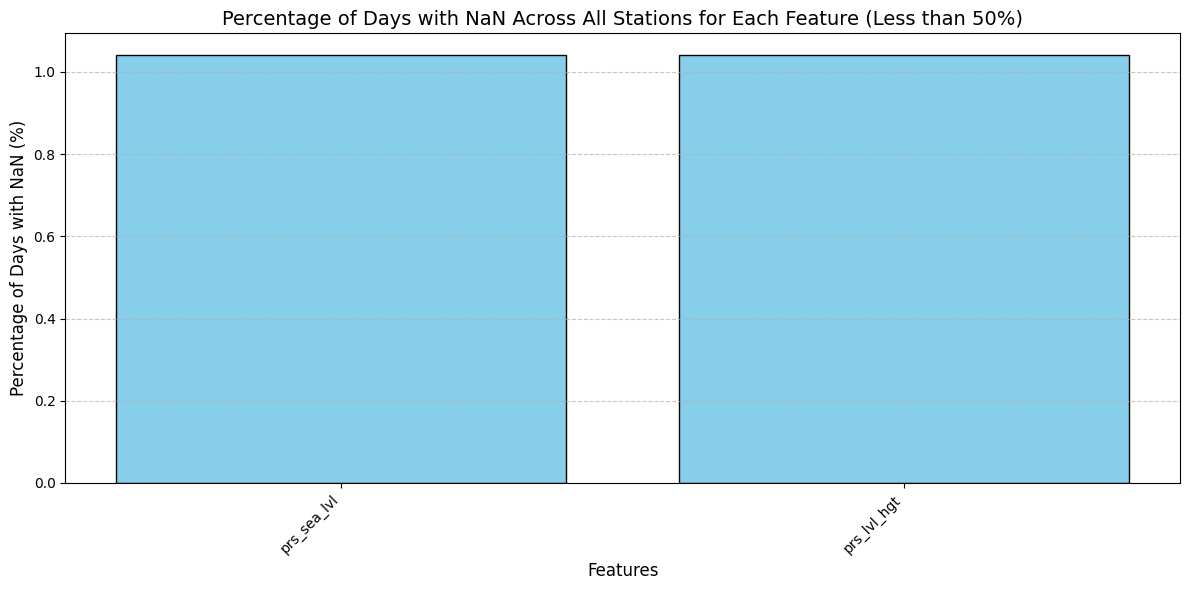


No features are 100% missing across all stations.


In [114]:
import matplotlib.pyplot as plt
import pandas as pd
import os
import pandas as pd

# 1. List of all station filenames using underscores instead of spaces, each ending in .csv
stations_names = [
    "AFULA_NIR_HAEMEQ.csv", "AMMIAD.csv", "AVNE_ETAN.csv",
    "AYYELET_HASHAHAR.csv", "BET_ZAYDA.csv", "DEIR_HANNA.csv",
    "EDEN_FARM.csv", "ESHHAR.csv", "GAMLA.csv",
    "KEFAR_NAHUM.csv", "MAALE_GILBOA.csv",
    "MASSADA.csv", "SEDE_ELIYYAHU.csv", "TAVOR_KADOORIE.csv",
    "TEL_YOSEF.csv", "YAVNEEL.csv", "ZEMAH.csv",

    "AFEQ.csv", "EN_HAHORESH.csv", "EN_HASHOFET.csv", "EN_KARMEL.csv", "GALED.csv",
    "HADERA_PORT.csv", "HAIFA_REFINERIES.csv", "HAIFA_TECHNION.csv", "HAIFA_UNIVERSITY.csv",
    "NEWE_YAAR.csv", "ROSH_HANIQRA.csv", "SHAVE_ZIYYON.csv", "ZIKHRON_YAAQOV.csv",

    "HARASHIM.csv", "MEROM_GOLAN_PICMAN.csv", "ZEFAT_HAR_KENAAN.csv",
    "DAFNA.csv", "KEFAR_BLUM.csv", "KEFAR_GILADI.csv",

    "ELAT.csv", "HAZEVA.csv", "PARAN.csv", "YOTVATA.csv", "NEOT_SMADAR.csv",

    "ARAD.csv", "ASHALIM.csv", "AVDAT.csv", "EZUZ.csv",
    "MIZPE_RAMON.csv", "NEVATIM.csv", "SEDE_BOQER.csv",
    "SHANI.csv", "ZOMET_HANEGEV.csv", "LAHAV.csv",

    "ASHDOD_PORT.csv", "ASHQELON_PORT.csv", "BEIT_JIMAL.csv", "BESOR_FARM.csv", "BET_DAGAN.csv",
    "DOROT.csv", "GAT.csv", "HAFEZ_HAYYIM.csv", "NAHSHON.csv", "NEGBA.csv",
    "NIZZAN.csv", "QEVUZAT_YAVNE.csv", "TEL_AVIV_COAST.csv",

    "HAR_HARASHA.csv", "JERUSALEM_CENTRE.csv", "JERUSALEM_GIVAT_RAM.csv", "ROSH_ZURIM.csv", "ZOVA.csv"
]

# 2. Dictionary to hold DataFrames for each station
stations = {}

# 3. Directory containing all station CSV files
load_directory = r"C:\תואר שני\מחקר נגה\נתונים שעתיים\Stations Daily Data New"

# 4. Define the cutoff year for filtering
cutoff_year = 2008

# 5. Loop over each station CSV file, load and clean
for file_name in stations_names:
    # Remove ".csv" from filename to get the station key
    station_name = os.path.splitext(file_name)[0]
    
    file_path = os.path.join(load_directory, file_name)

    try:
        # Read the CSV into a DataFrame
        df = pd.read_csv(file_path)

        # Ensure there's a 'Date' column before filtering
        if 'Date' in df.columns:
            df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
            # Filter rows to keep only records on or after cutoff_year
            df = df[df['Date'].dt.year >= cutoff_year]
        else:
            print(f"Warning: 'Date' column not found in {file_name}. Skipping date-based filtering.")

        # If 'Rain (degC)' exists, rename it to 'Rain (mm)'
        if 'Rain (degC)' in df.columns:
            df.rename(columns={'Rain (degC)': 'Rain (mm)'}, inplace=True)
            print(f"Renamed 'Rain (degC)' to 'Rain (mm)' in station: {file_name}")

        # Store the cleaned DataFrame in the stations dictionary
        stations[station_name] = df

    except Exception as e:
        print(f"Error processing file {file_name}: {e}")

# 6. Print verification of the final stations dictionary
print("Final cleaned stations dictionary:")
for st_name, st_df in stations.items():
    print(f"\n--- {st_name} ---")
    print(st_df.head())  # Print just the head for brevity



def plot_nan_diagrams_across_stations(stations):
    """
    Plot a single bar chart showing the percentage of days where all stations in the cluster
    have NaN for each feature, displaying only features with less than 50% missing values.
    Print features that are 100% missing across all stations.

    Args:
        stations (dict): A dictionary where keys are station names and values are DataFrames containing station data.
    """
    # Initialize a dictionary to store the percentage of null days across all stations for each feature
    null_days_percentage = {}

    # Get the list of features from the first station (assuming all stations have the same features)
    example_station = next(iter(stations.values()))
    features = example_station.columns

    # Loop through each feature
    for feature in features:
        if feature == "Date":  # Skip the Date column
            continue

        # Create a DataFrame to hold the feature values for all stations
        feature_data = pd.DataFrame()

        # Extract the feature column from each station
        for station_name, df in stations.items():
            if feature in df.columns:
                # Align by date and add to feature_data
                feature_data[station_name] = df.set_index('Date')[feature]

        # Calculate the percentage of days where all stations have NaN for the feature
        total_days = len(feature_data)
        if total_days > 0:
            null_percentage = (feature_data.isna().all(axis=1).sum() / total_days) * 100
        else:
            null_percentage = 0

        # Store the percentage in the dictionary
        null_days_percentage[feature] = null_percentage

    # Convert the results to a DataFrame for sorting and plotting
    null_days_df = pd.DataFrame(list(null_days_percentage.items()), columns=["Feature", "Null Days Percentage"])
    
    # Exclude features with 0% missing values and filter features with less than 50% missing values
    null_days_df = null_days_df[(null_days_df["Null Days Percentage"] > 0) & (null_days_df["Null Days Percentage"] < 50)]
    null_days_df = null_days_df.sort_values(by="Null Days Percentage", ascending=False)
    
    # Plot the bar chart if there are features to display
    if not null_days_df.empty:
        plt.figure(figsize=(12, 6))
        plt.bar(null_days_df["Feature"], null_days_df["Null Days Percentage"], color='skyblue', edgecolor='black')
        plt.title("Percentage of Days with NaN Across All Stations for Each Feature (Less than 50%)", fontsize=14)
        plt.xlabel("Features", fontsize=12)
        plt.ylabel("Percentage of Days with NaN (%)", fontsize=12)
        plt.xticks(rotation=45, ha='right', fontsize=10)
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()
    else:
        print("\nNo features with less than 50% missing values to display in the diagram.")
    
    # Find features that are 100% missing across all stations
    features_100_percent_missing_all_stations = [feature for feature, percentage in null_days_percentage.items() if percentage == 100]

    # Print features that are 100% missing across all stations
    if features_100_percent_missing_all_stations:
        print("\nFeatures 100% Missing Across All Stations:")
        for feature in sorted(features_100_percent_missing_all_stations):
            print(f"- {feature}")
    else:
        print("\nNo features are 100% missing across all stations.")

# Example Usage:
# Call the function with your stations dictionary
plot_nan_diagrams_across_stations(stations)



Feature Corelation

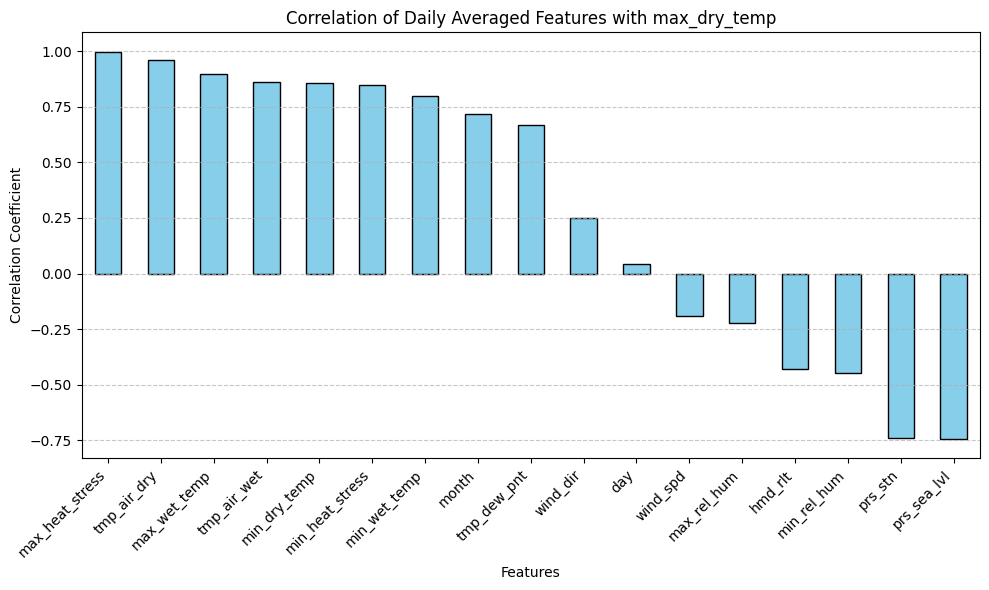

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_cluster_feature_correlations_daily_avg(cluster_stations, target_feature, exclude_features=None):
    """
    Calculate and plot the correlation of daily averaged features (across all stations)
    with the target feature, excluding specified features and features with zero correlation.

    Args:
        cluster_stations (dict): A dictionary where keys are station names and values are DataFrames.
        target_feature (str): The feature to which correlations are calculated (e.g., "max_dry_temp").
        exclude_features (list): List of features to exclude from the correlation analysis.

    Returns:
        None
    """
    if exclude_features is None:
        exclude_features = []

    # Initialize a DataFrame to store the sum of all stations
    daily_combined = None

    # Loop through each station
    for station, df in cluster_stations.items():
        # Select numeric columns only
        numeric_df = df.select_dtypes(include=['float64', 'int64'])
        
        # Aggregate daily data across all stations
        if daily_combined is None:
            daily_combined = numeric_df
        else:
            daily_combined = daily_combined.add(numeric_df, fill_value=0)

    # Calculate daily averages across stations
    daily_avg = daily_combined / len(cluster_stations)

    # Drop excluded features
    daily_avg = daily_avg.drop(columns=exclude_features, errors='ignore')

    # Ensure the target feature exists in the DataFrame
    if target_feature not in daily_avg.columns:
        raise ValueError(f"Target feature '{target_feature}' not found in the averaged data.")

    # Calculate correlations
    correlations = daily_avg.corr()[target_feature].drop(target_feature)

    # Filter out features with zero or near-zero correlation
    correlations = correlations[correlations.abs() > 0.01]  # Adjust threshold if necessary

    # Sort correlations for better visualization
    correlations = correlations.sort_values(ascending=False)

    # Check if there are any features left to plot
    if correlations.empty:
        print("No features have significant correlation with the target feature.")
        return

    # Plot the correlations
    plt.figure(figsize=(10, 6))
    correlations.plot(kind='bar', color='skyblue', edgecolor='black')
    plt.title(f"Correlation of Daily Averaged Features with {target_feature}")
    plt.xlabel("Features")
    plt.ylabel("Correlation Coefficient")
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# Example usage:
# Assuming `stations` is a dictionary where each key is a station name (e.g., "NEGBA") 
# and the value is a DataFrame of the station's data

plot_cluster_feature_correlations_daily_avg(
    cluster_stations=stations, 
    target_feature="max_dry_temp", 
    exclude_features=[]
)


Features Variance

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_feature_variance_daily_avg(cluster_stations, exclude_features=None):
    """
    Calculate and plot the variance of daily averaged features (across all stations)
    excluding specified features.

    Args:
        cluster_stations (dict): A dictionary where keys are station names and values are DataFrames.
        exclude_features (list): List of features to exclude from the variance calculation.

    Returns:
        None
    """
    if exclude_features is None:
        exclude_features = []

    # Initialize a DataFrame to store the sum of all stations
    daily_combined = None

    # Loop through each station
    for station, df in cluster_stations.items():
        # Select numeric columns only
        numeric_df = df.select_dtypes(include=['float64', 'int64'])
        
        # Aggregate daily data across all stations
        if daily_combined is None:
            daily_combined = numeric_df
        else:
            daily_combined = daily_combined.add(numeric_df, fill_value=0)

    # Calculate daily averages across stations
    daily_avg = daily_combined / len(cluster_stations)

    # Drop excluded features
    daily_avg = daily_avg.drop(columns=exclude_features, errors='ignore')

    # Calculate variance for each feature
    feature_variances = daily_avg.var()

    # Filter out features with zero variance
    feature_variances = feature_variances[feature_variances > 0]

    # Sort variances for better visualization
    feature_variances = feature_variances.sort_values(ascending=False)

    # Check if there are any features left to plot
    if feature_variances.empty:
        print("No features have significant variance.")
        return

    # Plot the variances
    plt.figure(figsize=(10, 6))
    feature_variances.plot(kind='bar', color='lightgreen', edgecolor='black')
    plt.title("Feature Variance Diagram (Daily Data)")
    plt.xlabel("Features")
    plt.ylabel("Variance")
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# Example usage:
# Assuming `stations` is a dictionary where each key is a station name (e.g., "NEGBA") 
# and the value is a DataFrame of the station's data

plot_feature_variance_daily_avg(
    cluster_stations=stations, 
    exclude_features=["prs_stn", "prs_sea_lvl", "prs_lvl_hgt"]
)


Channels Creation

In [35]:
from tqdm import tqdm
import numpy as np
import pandas as pd

def create_channels(pixel_matrix, weights_matrix, stations, selected_features, aggregation="daily"):
    """
    Create channels for each feature, where each channel is a grid of pixels weighted for the feature
    aggregated daily, weekly, or monthly.

    Parameters:
        pixel_matrix (numpy.ndarray): 3D array of pixel coordinates (longitude, latitude).
        weights_matrix (numpy.ndarray): 3D array of weights corresponding to each pixel and each station.
        stations (dict): Dictionary where keys are station names and values are DataFrames containing station data.
        selected_features (list): List of features to create channels for.
        aggregation (str): Aggregation level, one of ["daily", "weekly", "monthly"].

    Returns:
        dict: A dictionary where keys are feature names and values are lists of 2D numpy arrays (frames).
    """
    num_rows, num_cols, num_stations = weights_matrix.shape
    channels = {feature: [] for feature in selected_features}

    # Ensure all stations have 'Date' as a datetime index
    for station_name, df in stations.items():
        if 'Date' in df.columns:
            stations[station_name] = df.set_index('Date')

    # Determine unique time periods based on aggregation
    if aggregation == "daily":
        time_periods = pd.date_range(
            start=min(df.index.min() for df in stations.values()),
            end=max(df.index.max() for df in stations.values()),
            freq="D",
        )
    elif aggregation == "weekly":
        time_periods = pd.date_range(
            start=min(df.index.min() for df in stations.values()),
            end=max(df.index.max() for df in stations.values()),
            freq="W-MON",  # Weekly, starting on Monday
        )
    elif aggregation == "monthly":
        time_periods = pd.date_range(
            start=min(df.index.min() for df in stations.values()),
            end=max(df.index.max() for df in stations.values()),
            freq="MS",  # Monthly, starting at the beginning of the month
        )
    else:
        raise ValueError("Invalid aggregation. Choose from 'daily', 'weekly', or 'monthly'.")

    # Add progress bar for features
    with tqdm(total=len(selected_features) * len(time_periods), desc="Processing Features and Frames") as pbar:
        for feature in selected_features:
            for time_period_start in time_periods:
                if aggregation == "daily":
                    time_period_end = time_period_start
                elif aggregation == "weekly":
                    time_period_end = time_period_start + pd.Timedelta(days=6)
                elif aggregation == "monthly":
                    time_period_end = time_period_start + pd.offsets.MonthEnd(1)

                # Initialize an empty 2D array for the current frame
                frame = np.zeros((num_rows, num_cols))

                for i in range(num_rows):
                    for j in range(num_cols):
                        # Get weights for the current pixel
                        pixel_weights = weights_matrix[i, j, :]

                        # Get the feature values for all stations within the time period
                        feature_values = []
                        for station_index, station_name in enumerate(stations.keys()):
                            if feature in stations[station_name].columns:
                                station_df = stations[station_name].loc[time_period_start:time_period_end]
                                feature_value = station_df[feature].mean()  # Aggregate within the period
                                feature_values.append(feature_value)
                            else:
                                feature_values.append(np.nan)

                        # Convert feature values to a numpy array
                        feature_values = np.array(feature_values)

                        # Handle NaN values in feature_values
                        valid_mask = ~np.isnan(feature_values)
                        valid_weights = pixel_weights[valid_mask]
                        valid_values = feature_values[valid_mask]

                        # Calculate the weighted sum for the pixel
                        if valid_weights.sum() > 0:
                            weighted_value = np.sum(valid_weights * valid_values) / valid_weights.sum()
                        else:
                            weighted_value = np.nan  # Assign NaN if no valid weights exist

                        # Assign the weighted value to the pixel in the frame
                        frame[i, j] = weighted_value

                # Append the frame to the feature's list of frames
                channels[feature].append(frame)

                # Update progress bar
                pbar.update(1)

    return channels


In [36]:
# Define the features to process
selected_features = ["max_dry_temp"]

# Choose the aggregation level: "daily", "weekly", or "monthly"
aggregation = "daily"

# Create the channels
channels = create_channels(pixel_matrix, weights_exponential, stations, selected_features, aggregation)

# Example: Access and print the first frame of a feature
#for feature in selected_features:
  # print(f"First frame for feature '{feature}':")
   # print(channels[feature][213])  # The first frame for the feature
    #print()


Processing Features and Frames: 100%|██████████| 305/305 [00:08<00:00, 37.92it/s]


Heat MAP for 01/08/2020

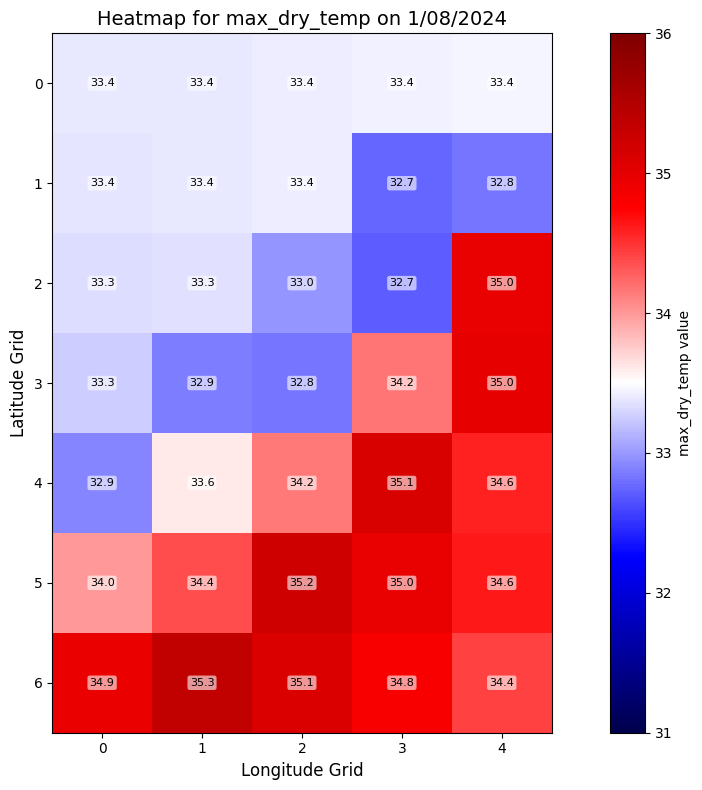

In [41]:
import matplotlib.pyplot as plt
import numpy as np

# Define the date you want to visualize (1/08/2020 corresponds to index 213 since data starts on 1/1/2020)
date_index = 213  # Day 214 (August 1), zero-indexed

# Set vmin and vmax to control the sensitivity (adjust these based on your data)
vmin = 31  # Minimum value for the color scale
vmax = 36  # Maximum value for the color scale

# Plot heatmaps for the selected features on 1/08/2020
for feature in selected_features:
    if date_index < len(channels[feature]):  # Ensure the date index is within bounds
        data = channels[feature][date_index]  # Get the frame for the specific date

        # Rotate the data 90 degrees counterclockwise
        data = np.rot90(data)

        # Create the heatmap with the correct orientation
        plt.figure(figsize=(12, 8))  # Adjust width for proper visualization of rotated grids
        plt.imshow(data, cmap='seismic', interpolation='nearest', vmin=vmin, vmax=vmax)  # Use default aspect ratio
        plt.colorbar(label=f"{feature} value")
        plt.title(f"Heatmap for {feature} on 1/08/2024", fontsize=14)
        plt.xlabel("Longitude Grid", fontsize=12)
        plt.ylabel("Latitude Grid", fontsize=12)

        # Add values to each square
        num_rows, num_cols = data.shape
        for i in range(num_rows):
            for j in range(num_cols):
                value = data[i, j]
                if not np.isnan(value):  # Only annotate non-NaN values
                    plt.text(
                        j, i, f"{value:.1f}",  # Format values to one decimal point
                        ha='center', va='center', color='black', fontsize=8, 
                        bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.2', alpha=0.6)
                    )

        # Adjust layout for better readability
        plt.tight_layout()
        plt.show()
    else:
        print(f"Date index {date_index} is out of bounds for feature '{feature}'.")


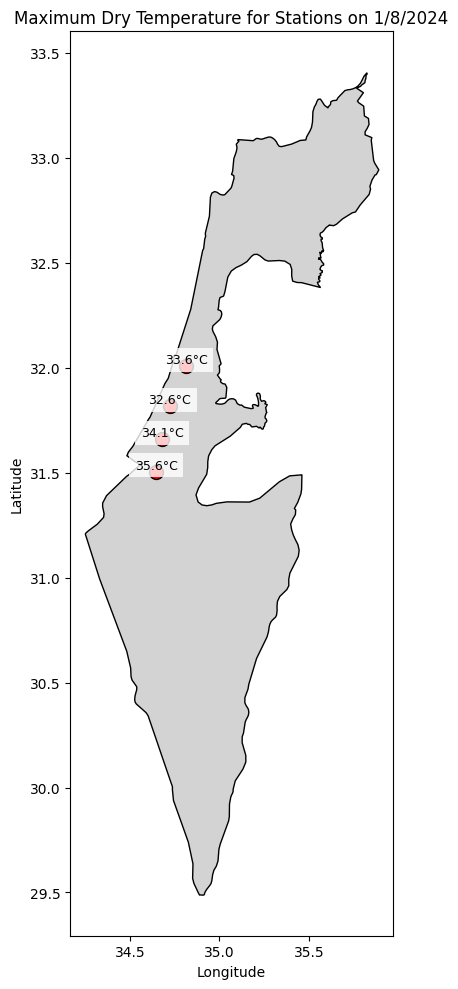

In [42]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

# List of selected station names to plot
cluster = [
     
    "BET DAGAN", "DOROT",   
    "NEGBA", "QEVUZAT YAVNE"
]

# Load station metadata from CSV
stations_df = pd.read_csv('C:\\תואר שני\\מחקר נגה\\Map plottings\\stations_meta_data.csv')  # Adjust path

# Normalize station names for matching
stations_df['Station'] = stations_df['Station'].str.upper()
stations_df['Station'] = stations_df['Station'].str.replace('STATION_', '').str.replace('_', ' ')

# Filter to keep only the stations that are part of the specified cluster list and drop duplicates
stations_df = stations_df[stations_df['Station'].isin(cluster)].drop_duplicates(subset=['Station'])

# Load Israel map from GeoJSON
israel_map = gpd.read_file('C:\\תואר שני\\מחקר נגה\\Map plottings\\il.json')  # Adjust path

# Convert filtered DataFrame to GeoDataFrame for plotting
gdf_clustered_stations = gpd.GeoDataFrame(
    stations_df, geometry=gpd.points_from_xy(stations_df.Longitude, stations_df.Latitude)
)

# Define the target date (1/07/2023)
target_date = (2024, 8, 1)

# Annotate each station with its dry_temp_max for the target date
temperatures = []
for station_name, df in stations.items():
    # Filter for the target date
    selected_date = df[(df['day'] == target_date[2]) & (df['month'] == target_date[1]) & (df['year'] == target_date[0])]
    if not selected_date.empty:
        temp = selected_date['max_dry_temp'].values[0]  # Take the first value if multiple rows match
        temperatures.append(temp)
    else:
        temperatures.append(None)

# Ensure the temperatures list matches the length of gdf_clustered_stations
if len(temperatures) != len(gdf_clustered_stations):
    print(f"Warning: Length of temperatures ({len(temperatures)}) does not match number of stations ({len(gdf_clustered_stations)}).")

# Add temperature annotations to the GeoDataFrame
gdf_clustered_stations['Temperature'] = temperatures

# Plot the map with clustered stations
fig, ax = plt.subplots(figsize=(10, 10))

# Plot the base map of Israel
israel_map.plot(ax=ax, color='lightgray', edgecolor='black')

# Plot the clustered stations with temperature annotations
sc = ax.scatter(
    gdf_clustered_stations['Longitude'], 
    gdf_clustered_stations['Latitude'], 
    color='red', 
    s=100, 
    edgecolor='black'
)

# Annotate the stations with their temperatures
for _, row in gdf_clustered_stations.iterrows():
    if not pd.isna(row['Temperature']):
        ax.text(
            row['Longitude'], row['Latitude'], f"{row['Temperature']:.1f}°C",
            fontsize=9, ha='center', va='bottom', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none')
        )

# Set labels and title
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title(f"Maximum Dry Temperature for Stations on {target_date[2]}/{target_date[1]}/{target_date[0]}")

# Show plot
plt.tight_layout()
plt.show()


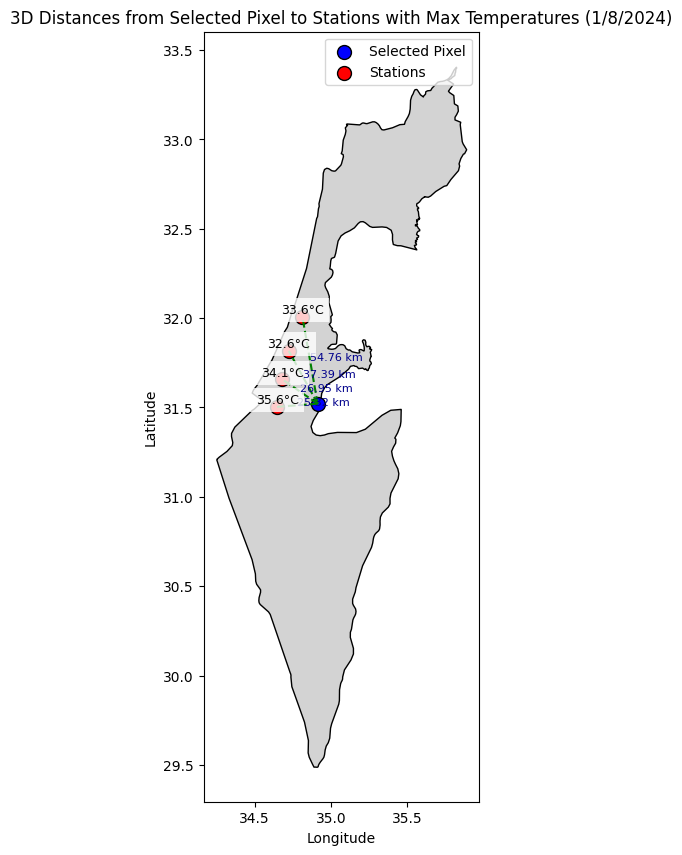

In [43]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from geopy.distance import geodesic

def plot_pixel_to_station_distances_with_temp(pixel, stations_df, israel_map, stations, target_date):
    """
    Plot lines from a chosen pixel to all stations, annotate 3D distances, and add temperature annotations.

    Args:
        pixel (tuple): Longitude, latitude, and elevation of the selected pixel (lon, lat, height).
        stations_df (GeoDataFrame): DataFrame containing station locations with 'Longitude', 'Latitude', and 'height'.
        israel_map (GeoDataFrame): GeoDataFrame of the Israel map for context.
        stations (dict): Dictionary containing station names as keys and DataFrames with weather data as values.
        target_date (tuple): Date in (year, month, day) format for temperature retrieval.
    """
    # Ensure the pixel is correctly unpacked
    pixel_lon, pixel_lat, pixel_height = pixel

    # Calculate 3D distances from the pixel to all stations
    stations_df['Horizontal Distance (km)'] = stations_df.apply(
        lambda row: geodesic((pixel_lat, pixel_lon), (row['Latitude'], row['Longitude'])).kilometers, axis=1
    )
    stations_df['Elevation Difference (m)'] = stations_df['height'] - pixel_height
    stations_df['Elevation Difference (km)'] = stations_df['Elevation Difference (m)'] / 1000.0

    # Compute True 3D Distance using Pythagoras
    stations_df['3D Distance (km)'] = np.sqrt(
        stations_df['Horizontal Distance (km)']**2 + stations_df['Elevation Difference (km)']**2
    )

    # Retrieve temperature data
    temperatures = []
    for station_name, df in stations.items():
        selected_date = df[
            (df['day'] == target_date[2]) & 
            (df['month'] == target_date[1]) & 
            (df['year'] == target_date[0])
        ]
        if not selected_date.empty:
            temp = selected_date['max_dry_temp'].values[0]
            temperatures.append(temp)
        else:
            temperatures.append(None)

    # Ensure temperatures match station count
    if len(temperatures) != len(stations_df):
        print(f"Warning: Mismatch in temperature data ({len(temperatures)}) vs. stations ({len(stations_df)}).")
    
    # Add temperature data to DataFrame
    stations_df['Temperature'] = temperatures

    # Create the plot
    fig, ax = plt.subplots(figsize=(10, 10))

    # Plot the base map of Israel
    israel_map.plot(ax=ax, color='lightgray', edgecolor='black')

    # Plot the chosen pixel
    ax.scatter(pixel_lon, pixel_lat, color='blue', s=100, label='Selected Pixel', edgecolor='black')

    # Plot the stations
    ax.scatter(
        stations_df['Longitude'], 
        stations_df['Latitude'], 
        color='red', 
        s=100, 
        label='Stations', 
        edgecolor='black'
    )

    # Draw lines and annotate 3D distances
    for _, row in stations_df.iterrows():
        station_lon, station_lat = row['Longitude'], row['Latitude']
        distance_3d_km = row['3D Distance (km)']

        # Draw line from pixel to station
        ax.plot([pixel_lon, station_lon], [pixel_lat, station_lat], color='green', linestyle='--')

        # Annotate 3D distance
        mid_lon, mid_lat = (pixel_lon + station_lon) / 2, (pixel_lat + station_lat) / 2
        ax.text(mid_lon, mid_lat, f'{distance_3d_km:.2f} km', fontsize=8, color='darkblue')

        # Annotate temperature
        if not pd.isna(row['Temperature']):
            ax.text(
                station_lon, station_lat, f"{row['Temperature']:.1f}°C",
                fontsize=9, ha='center', va='bottom', 
                bbox=dict(facecolor='white', alpha=0.8, edgecolor='none')
            )

    # Set labels, title, and legend
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.title(f'3D Distances from Selected Pixel to Stations with Max Temperatures ({target_date[2]}/{target_date[1]}/{target_date[0]})')
    ax.legend()

    # Show the plot
    plt.show()

# Example usage
chosen_pixel = tuple(pixel_matrix[4][1])  # Example pixel coordinates (Longitude, Latitude, Height)
target_date = (2024, 8, 1)  # Date for temperature annotation

plot_pixel_to_station_distances_with_temp(pixel=chosen_pixel, stations_df=gdf_clustered_stations, israel_map=israel_map, stations=stations, target_date=target_date)


[ 34.9138      31.52088333 385.        ]


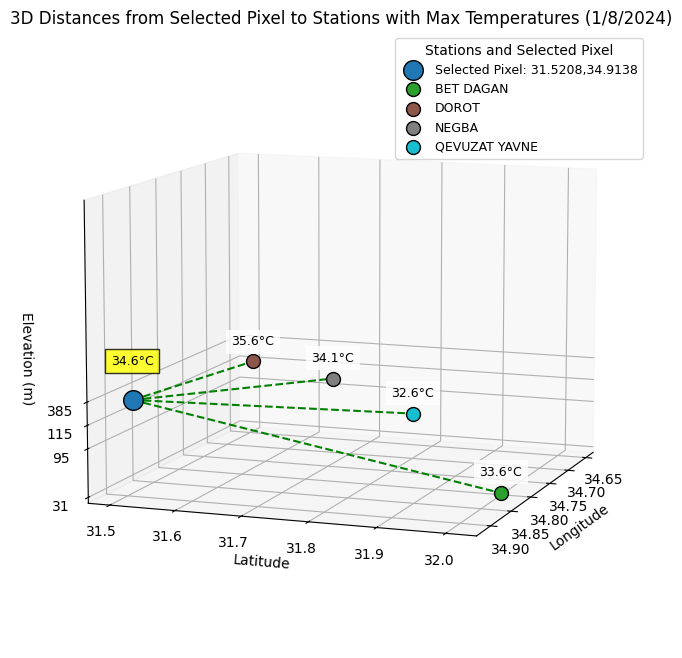

In [50]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from geopy.distance import geodesic
from mpl_toolkits.mplot3d import Axes3D

def plot_pixel_to_station_distances_with_temp_3d(
    pixel, pixel_name, pixel_temp, stations_df, stations, target_date, base_scale=0.001
):
    """
    Plot a 3D map showing distances from a chosen pixel to all stations, 
    including elevation differences and temperature annotations.
    """

    # Unpack the pixel data
    pixel_lon, pixel_lat, pixel_height = pixel

    # Calculate min and max heights across all stations
    min_height = stations_df['height'].min()
    max_height = stations_df['height'].max()

    # Log-scaling
    stations_df['Log Height'] = np.log1p(stations_df['height'] - min_height)
    pixel_log_height = np.log1p(pixel_height - min_height)

    # Scale the log-heights
    log_min = stations_df['Log Height'].min()
    log_max = stations_df['Log Height'].max()

    stations_df['Scaled Height'] = (stations_df['Log Height'] - log_min) * base_scale
    pixel_scaled_height = (pixel_log_height - log_min) * base_scale

    # Store real heights (for labeling)
    stations_df['Real Height'] = stations_df['height']
    pixel_real_height = pixel_height

    # Calculate 3D distances
    stations_df['Horizontal Distance (km)'] = stations_df.apply(
        lambda row: geodesic(
            (pixel_lat, pixel_lon),
            (row['Latitude'], row['Longitude'])
        ).kilometers,
        axis=1
    )
    stations_df['Elevation Difference (m)'] = stations_df['height'] - pixel_height
    stations_df['3D Distance (km)'] = np.sqrt(
        stations_df['Horizontal Distance (km)']**2 
        + (stations_df['Elevation Difference (m)'] / 1000.0) ** 2
    )

    # Retrieve temperature data
    temperatures = []
    for station_name, df in stations.items():
        selected_date = df[
            (df['day'] == target_date[2]) &
            (df['month'] == target_date[1]) &
            (df['year'] == target_date[0])
        ]
        if not selected_date.empty:
            temp = selected_date['max_dry_temp'].values[0]
            temperatures.append(temp)
        else:
            temperatures.append(None)

    if len(temperatures) != len(stations_df):
        print("Warning: Mismatch in temperature data vs. stations.")

    stations_df['Temperature'] = temperatures

    # Create a 3D plot
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Set Z-axis limits
    z_min = stations_df['Scaled Height'].min()
    z_max = stations_df['Scaled Height'].max()
    ax.set_zlim(z_min, z_max * 4)

    # **Set Z-axis labels to real elevation values for the pixel and stations**
    tick_positions = [pixel_scaled_height] + [h for i, h in enumerate(stations_df['Scaled Height']) if i != 2]
    tick_labels = [int(round(pixel_real_height, 0))] + [h for i, h in enumerate(stations_df['Real Height'].astype(int)) if i != 3]

    ax.set_zticks(tick_positions)
    ax.set_zticklabels(tick_labels)

    # Adjust the viewing angle
    ax.view_init(elev=10, azim=20)

    # Assign unique colors to stations for the legend
    np.random.seed(42)  # Ensure color consistency
    station_colors = plt.cm.tab10(np.linspace(0, 1, len(stations_df) + 1))  # +1 for the pixel
    scatter_points = []

    # Plot the pixel with unique color
    pixel_sc = ax.scatter(
        pixel_lon, pixel_lat, pixel_scaled_height,
        color=station_colors[0], s=200, edgecolor='black'
    )
    scatter_points.append((pixel_sc, f"Selected Pixel: {pixel_name}"))  # Store for the legend

    # Plot the stations with unique colors
    for i, (station_name, row) in enumerate(stations_df.iterrows()):
        sc = ax.scatter(
            row['Longitude'], row['Latitude'], row['Scaled Height'],
            color=station_colors[i + 1], s=100, edgecolor='black'
        )
        scatter_points.append((sc, row['Station']))  # Store for the legend

    # Draw lines & annotate temperatures
    for _, row in stations_df.iterrows():
        station_lon = row['Longitude']
        station_lat = row['Latitude']
        station_scaled_height = row['Scaled Height']

        # Line from pixel to station
        ax.plot(
            [pixel_lon, station_lon],
            [pixel_lat, station_lat],
            [pixel_scaled_height, station_scaled_height],
            color='green', linestyle='--'
        )

        # Annotate temperature (if available)
        if not pd.isna(row['Temperature']):
            ax.text(
                station_lon, station_lat, station_scaled_height + 0.0009,
                f"{row['Temperature']:.1f}°C",
                fontsize=9, ha='center', va='bottom',
                bbox=dict(facecolor='white', alpha=0.8, edgecolor='none')
            )

    # Annotate the selected pixel with its **calculated temperature**
    ax.text(
        pixel_lon, pixel_lat, pixel_scaled_height + 0.002,  # Offset slightly higher
        f"{pixel_temp:.1f}°C",
        fontsize=9, ha='center', va='bottom',
        bbox=dict(facecolor='yellow', alpha=0.8, edgecolor='black')
    )

    # Add legend for stations and selected pixel
    ax.legend(
        [sc[0] for sc in scatter_points],  # Markers
        [name for _, name in scatter_points],  # Station names & pixel name
        title="Stations and Selected Pixel",
        loc="upper right",
        fontsize=9
    )

    # Final labeling & title
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_zlabel('Elevation (m)')  
    ax.set_title(
        f'3D Distances from Selected Pixel to Stations '
        f'with Max Temperatures ({target_date[2]}/{target_date[1]}/{target_date[0]})'
    )

    # Show the plot
    plt.show()


# ------------------ USAGE EXAMPLE ------------------

chosen_pixel = tuple(pixel_matrix[4][1]) 
print(pixel_matrix[4][1])  # Example pixel (Longitude, Latitude, Height)
pixel_name = "31.5208,34.9138"  # Example name for the selected pixel

# **Retrieve the selected pixel temperature from the heatmap**
pixel_temp = heatmap_data[4, 1]  # Extract temperature from the matrix

target_date = (2024, 8, 1)  # Example date

plot_pixel_to_station_distances_with_temp_3d(
    pixel=chosen_pixel, 
    pixel_name=pixel_name,  # Pass the selected pixel name
    pixel_temp=pixel_temp,  # Pass the calculated temperature
    stations_df=gdf_clustered_stations,  # GeoDataFrame with station locations
    stations=stations,  # Dict of station weather data
    target_date=target_date
)


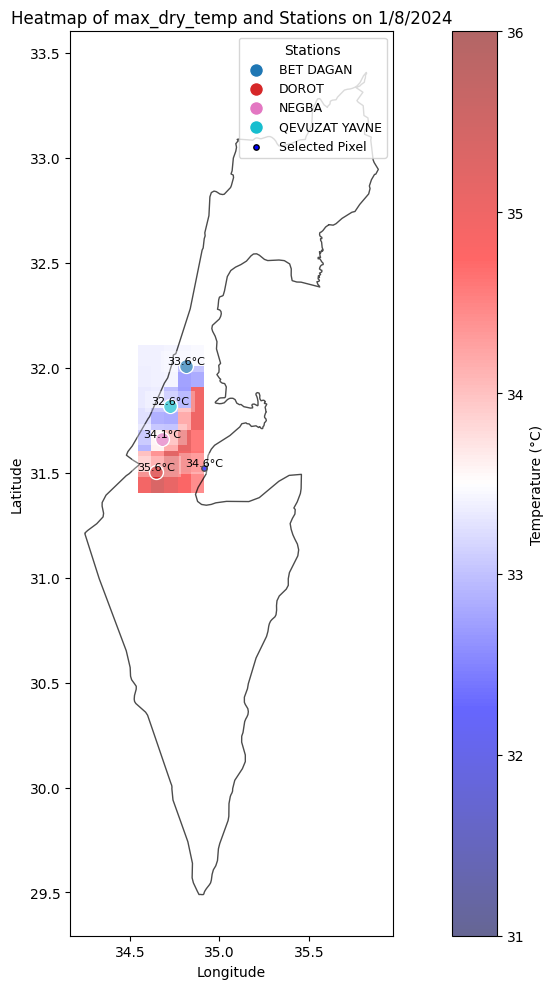

In [45]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np

# Define the target date (1/08/2024)
date_index = 213  # Corresponding to 1st August 2024
target_date = (2024, 8, 1)  # For labeling purposes

# Heatmap parameters
vmin, vmax = 31, 36  # Adjust based on your data range
feature_to_plot = "max_dry_temp"  # Choose the feature for the heatmap

# List of selected station names to plot
cluster = [
     "BET DAGAN",
    "DOROT", "NEGBA",
    "QEVUZAT YAVNE"
]

# Load station metadata
stations_df = pd.read_csv('C:\\תואר שני\\מחקר נגה\\Map plottings\\stations_meta_data.csv')  
stations_df['Station'] = stations_df['Station'].str.upper()
stations_df['Station'] = stations_df['Station'].str.replace('STATION_', '').str.replace('_', ' ')
stations_df = stations_df[stations_df['Station'].isin(cluster)].drop_duplicates(subset=['Station'])

# Load Israel map
israel_map = gpd.read_file('C:\\תואר שני\\מחקר נגה\\Map plottings\\il.json')  

# Convert station data to GeoDataFrame
gdf_clustered_stations = gpd.GeoDataFrame(
    stations_df, geometry=gpd.points_from_xy(stations_df['Longitude'], stations_df['Latitude'])
)

# Annotate each station with its max_dry_temp for the target date
temperatures = []
for station_name, df in stations.items():
    selected_date = df[
        (df['day'] == target_date[2]) & 
        (df['month'] == target_date[1]) & 
        (df['year'] == target_date[0])
    ]
    if not selected_date.empty:
        temp = selected_date['max_dry_temp'].values[0]  # Take the first value
        temperatures.append(temp)
    else:
        temperatures.append(None)

# Ensure the temperatures list matches the length of gdf_clustered_stations
if len(temperatures) != len(gdf_clustered_stations):
    print(f"Warning: Length of temperatures ({len(temperatures)}) does not match number of stations ({len(gdf_clustered_stations)}).")

# Add temperature annotations to the GeoDataFrame
gdf_clustered_stations['Temperature'] = temperatures

# Extract heatmap data for the selected date and feature
heatmap_data = channels[feature_to_plot][date_index]  # Heatmap data for the specific date

# Rotate the heatmap to ensure correct orientation
heatmap_data_rotated = np.rot90(heatmap_data)

# Define grid extents based on pixel matrix
lon_min, lon_max = gdf_clustered_stations['Longitude'].min(), gdf_clustered_stations['Longitude'].max()
lat_min, lat_max = gdf_clustered_stations['Latitude'].min(), gdf_clustered_stations['Latitude'].max()
lon_padding, lat_padding = 0.1, 0.1  # Adjust padding
grid_lon_extent = (lon_min - lon_padding, lon_max + lon_padding)
grid_lat_extent = (lat_min - lat_padding, lat_max + lat_padding)

# **Retrieve the selected pixel coordinates**
selected_pixel_lon, selected_pixel_lat, _ = pixel_matrix[4][1]  # Extract Lon, Lat

# **Retrieve the selected pixel temperature value**
selected_pixel_value = heatmap_data[4, 1]  # Extract value from the heatmap

# Plot the heatmap with stations overlaid
fig, ax = plt.subplots(figsize=(12, 10))

# Plot the heatmap grid
im = ax.imshow(
    heatmap_data_rotated,
    extent=[grid_lon_extent[0], grid_lon_extent[1], grid_lat_extent[0], grid_lat_extent[1]],
    cmap='seismic',
    alpha=0.6,
    origin='upper',  # Correct orientation for map alignment
    vmin=vmin,
    vmax=vmax
)

# Add colorbar
plt.colorbar(im, ax=ax, label="Temperature (°C)")

# Assign unique colors to stations for the legend
station_colors = plt.cm.tab10(np.linspace(0, 1, len(gdf_clustered_stations)))
scatter_points = []

# Plot the clustered stations on top of the heatmap with unique colors
for i, (station_name, row) in enumerate(gdf_clustered_stations.iterrows()):
    sc = ax.scatter(
        row['Longitude'], row['Latitude'], 
        color=station_colors[i], 
        s=100, 
        edgecolor='white'
    )
    scatter_points.append((sc, row['Station']))  # Store for the legend with station names

# **Plot the selected pixel (highlighted)**
selected_pixel_scatter = ax.scatter(
    selected_pixel_lon, selected_pixel_lat, 
    color='blue', 
    s=15, 
    edgecolor='black',
    label="Selected Pixel"
)

# Annotate the stations with their temperatures
for _, row in gdf_clustered_stations.iterrows():
    if not pd.isna(row['Temperature']):
        ax.text(
            row['Longitude'], row['Latitude'], f"{row['Temperature']:.1f}°C",
            fontsize=8, ha='center', va='bottom', bbox=dict(facecolor='white', alpha=0.3, edgecolor='none')
        )

# **Annotate the selected pixel with its value**
ax.text(
    selected_pixel_lon, selected_pixel_lat, f"{selected_pixel_value:.1f}°C",
    fontsize=8, ha='center', va='bottom', bbox=dict(facecolor='white', alpha=0.3, edgecolor='none')
)

# Plot the Israel map for context
israel_map.plot(ax=ax, color='none', edgecolor='black', alpha=0.7)

# **Add legend for stations and selected pixel**
ax.legend(
    [sc for sc, _ in scatter_points] + [selected_pixel_scatter],  # Markers
    [name for _, name in scatter_points] + ["Selected Pixel"],  # Station names + Selected Pixel
    title="Stations",
    loc="upper right",
    fontsize=9
)

# Set labels and title
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title(f"Heatmap of {feature_to_plot} and Stations on {target_date[2]}/{target_date[1]}/{target_date[0]}")

# Show plot
plt.tight_layout()
plt.show()
